In [1]:
import discovery as ds
import jax
import discovery.samplers.numpyro as ds_numpyro
from matplotlib import pyplot as plt
import corner
import numpy as np

In [4]:
psr = ds.Pulsar.read_feather("sim4.feather")

In [5]:
signals = [
    psr.residuals,
    ds.makenoise_measurement_simple(psr),
    ds.makegp_fourier(psr, ds.powerlaw, fourierbasis=ds.dmfourierbasis, components=30, name='dmgp'),
    ds.makegp_timing(psr),
]

In [6]:
psl = ds.PulsarLikelihood(signals)

In [7]:
p0 = ds.sample_uniform(psl.logL.params)
print(p0)

{'SIM2_dmgp_gamma': 0.8885912972226941, 'SIM2_dmgp_log10_A': -18.80141820473581, 'SIM2_efac': 0.7217175757066179, 'SIM2_log10_t2equad': -6.557825676895935}


In [8]:
psl.logL(p0), jax.grad(psl.logL)(p0)

(Array(-51970.71018755, dtype=float64),
 {'SIM2_dmgp_gamma': Array(0.0003917, dtype=float64, weak_type=True),
  'SIM2_dmgp_log10_A': Array(0.00081948, dtype=float64, weak_type=True),
  'SIM2_efac': Array(217740.06765921, dtype=float64, weak_type=True),
  'SIM2_log10_t2equad': Array(39670.96667419, dtype=float64, weak_type=True)})

In [17]:
npmodel = ds_numpyro.makemodel_transformed(psl.logL)
npsampler = ds_numpyro.makesampler_nuts(npmodel, num_warmup=1024, num_samples=2048)

In [18]:
npsampler.run(jax.random.PRNGKey(np.random.randint(1)))

sample: 100%|██████████| 3072/3072 [05:46<00:00,  8.88it/s, 1 steps of size 1.59e-01. acc. prob=0.73]   


In [19]:
chain = npsampler.to_df()

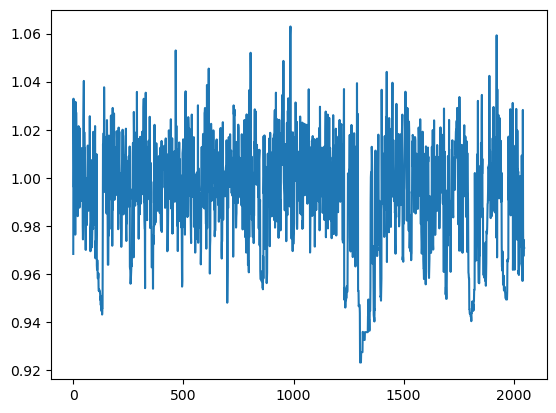

In [20]:
plt.plot(chain["SIM2_efac"].array)

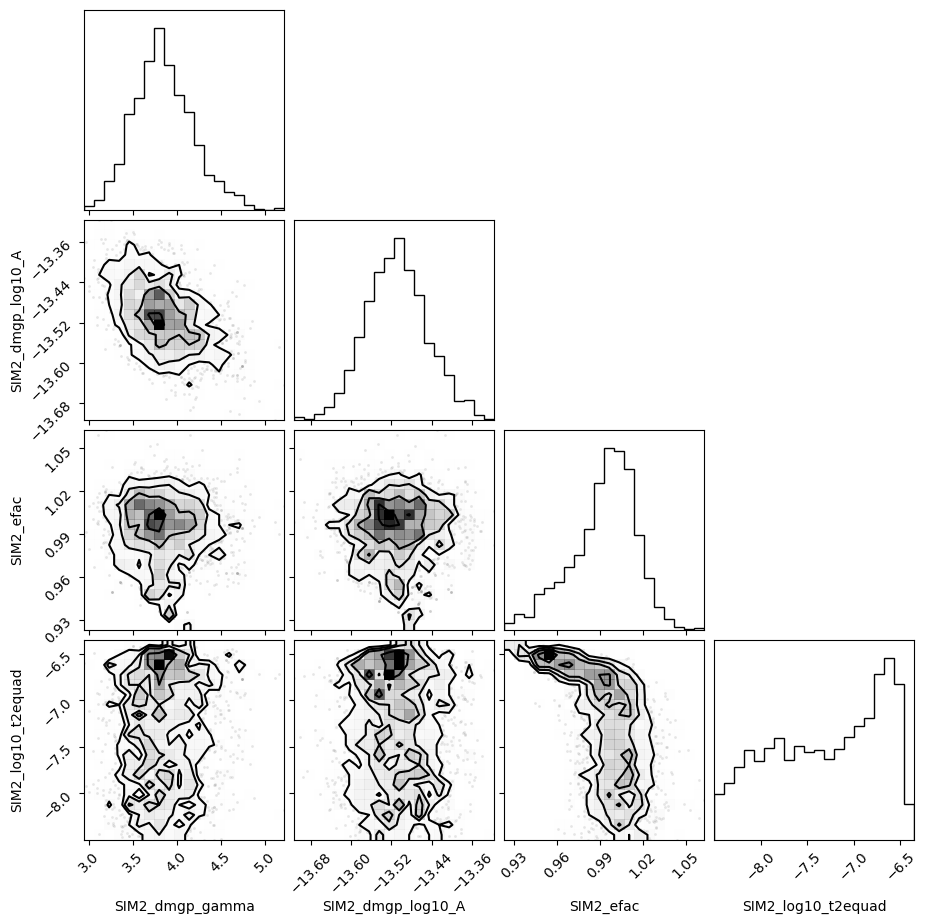

In [21]:
corner.corner(chain.to_numpy(), labels=psl.logL.params);